In [6]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# The Problem


Power generation is one of the most important features in Canadian infrastructure today. There are many difference faucets of power generation, and all of them must work in unison to ensure the structural integrity of the power grid.

One of the more difficult aspects of this task is the prediction of power generation. Power is not first requested and then distributed, it must be available on demand at the time of use. This creates an interesting issue, involving a lot of data analysis and preparation where the useage of power must be predicted before it is actually used. Generating too little power will cause interruptions in what could be other critical infrastructure such as hospitals. Generating much more power than is used is not only a huge waste of resources, but may also damage the infrastructure that is used to distribute and store this energy.

With the collection of sufficient data, I believe that machine learning could be a useful tool to help engineers predict the amount of power usage given a specific time in the year, along with other parameters. This model will of course not be a perfect one, and redundant power generation will always be a source of at least some waste; however, the goal of reducing this waste has the potential for positive economic and environmental benefits.

When it comes to expectations of the data, this will largely depend on where the data set is coming from. In this case, the dataset is obtained from Tetouan City in Morocco in 2017.  Morocco is just South of Portugal and Spain, and is on the coast of the North Atlantic ocean. Morocco's climate is described as "Mediterranian" or having a hot summer climate. Since we expect the summer period to be more uncomfortable than the other seasons, we should see an increase in the amount of electricity used in climate control of the city during the summer.

In terms of population, the city of Tetouan population census since in 2017 was counted at around 400,000 people. This is small compared to some of the cities that this technology may be used in, but it could be reasoned that the smaller population makes this a much better candidate for testing the application of machine learning for this process. Since the population is smaller, it is likely there will be more noise in the data since less changes in the use of power will be required to have an appreciable effect on the total power of the system.

As mentioned previously, the goal is not to predict the exact power useage, rather to give a better chance to overestimate an amount such that the economic and environmental impact of power generation can be reduced. We will analyze the data to see what could possibly have the greatest effect on the machine learning model to best predict the power useage.

# Objective and Approach

The objective of this program will be to accurate predict with an $R^{2}$ that is at least consistently close to 1.



# Preliminary Analysis

First the data will be analyzed as a function of time in order to depict any trends we may find that show what may be good data sets to include in the training set.

                     Temperature   Humidity  Wind Speed  \
DateTime                                                  
2017-01-01 00:00:00     5.497681  73.529583    0.554056   
2017-01-01 12:00:00    13.852917  63.509028    0.076236   
2017-01-02 00:00:00    10.675833  79.206528    0.077431   
2017-01-02 12:00:00    14.277917  63.706111    0.075694   
2017-01-03 00:00:00    11.427778  76.832500    0.078625   
...                          ...        ...         ...   
2017-12-28 12:00:00    13.714583  49.920972    0.078083   
2017-12-29 00:00:00    12.155417  50.619861    0.078167   
2017-12-29 12:00:00    13.825556  47.537639    0.078194   
2017-12-30 00:00:00    11.910556  49.451528    0.077847   
2017-12-30 12:00:00    11.467431  53.271806    0.078500   

                     General Diffuse Flows  Diffuse Flows  \
DateTime                                                    
2017-01-01 00:00:00              71.700667       8.392375   
2017-01-01 12:00:00             171.080875      4

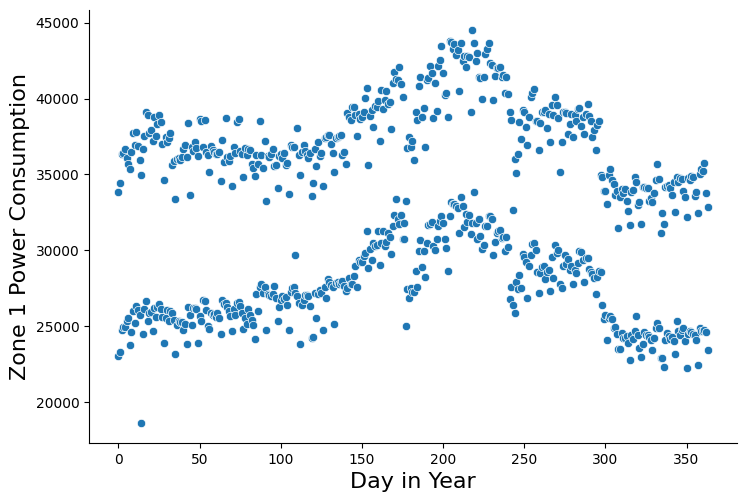

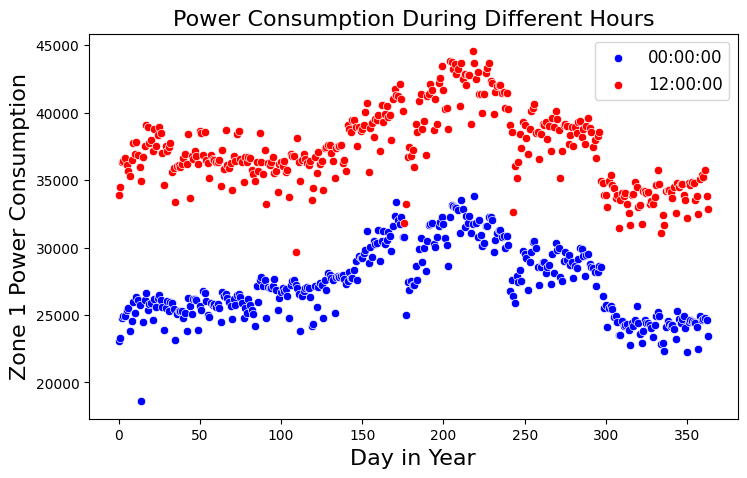

In [7]:
trueData = pd.read_csv("C:/Users/fancy/OneDrive - University of Guelph/Documents/Colab Notebooks/CS 4120 Assignments/Tetuan City power consumption.csv", header=None, names=['DateTime',
                                                                                'Temperature',
                                                                                'Humidity',
                                                                                'Wind Speed',
                                                                                'General Diffuse Flows',
                                                                                'Diffuse Flows',
                                                                                'Zone 1 Power Consumption',
                                                                                'Zone 2 Power Consumption',
                                                                                'Zone 3 Power Consumption'], skiprows=1)

trueData['DateTime'] = pd.to_datetime(trueData['DateTime'], errors='coerce', format='%m/%d/%Y %H:%M')

trueData.set_index('DateTime', inplace=True)

# Resample the data such that we are now measuring over every 12h in the year of the dataset
rawData = trueData.resample('12h').mean()

rawData['Day'] = (rawData.index - rawData.index.min()).days

rawData_midnight = rawData[rawData.index.time == pd.Timestamp("00:00:00").time()]

rawData_noon = rawData[rawData.index.time == pd.Timestamp("12:00:00").time()]

print(rawData)

sns.pairplot(rawData, x_vars=['Day'], y_vars=['Zone 1 Power Consumption'], height=5, aspect=1.5)
plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.xlabel('Day in Year', fontsize=16)
plt.show()

plt.figure(figsize=(8.37, 5))
sns.scatterplot(data=rawData_midnight, x='Day', y='Zone 1 Power Consumption', color='blue', label='00:00:00')
sns.scatterplot(data=rawData_noon, x='Day', y='Zone 1 Power Consumption', color='red', label='12:00:00')

plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.xlabel('Day in Year', fontsize=16)
plt.title('Power Consumption During Different Hours', fontsize=16)
plt.legend(fontsize=12)
plt.show()



Here we have the mean power useage over every 12 hours in Zone 1 of Tetouan city. We can clearly see here that there are two trends that are nearly identical qualitatively, but are displaced by some constant in the y direction. This could be a consequence of how we have chosen to take the mean of the data every 12 hours, where it is hypothesized that the trend with a higher power useage would be the mean from 1200 to 0000, and the lower power useage being from 0000 to 1200.

This presents an interesting opportunity where we could train two models to provide clearer trends with less data, or we could simply train a single model that will need to account for more drastic changes in the data while maintaining the entire data set to be trained on.

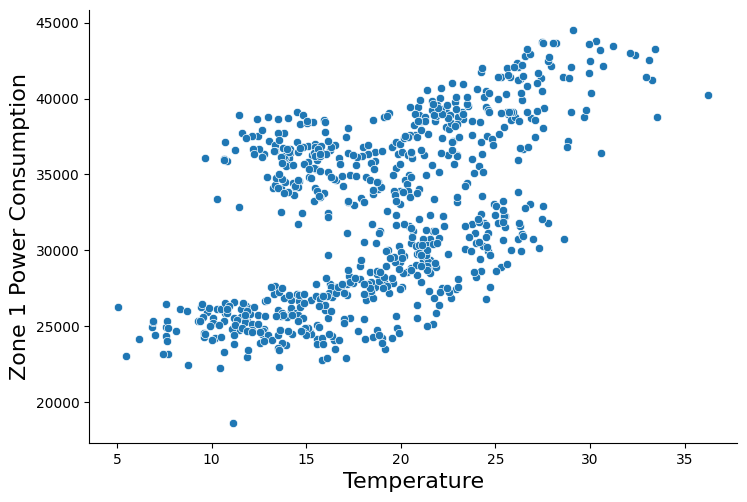

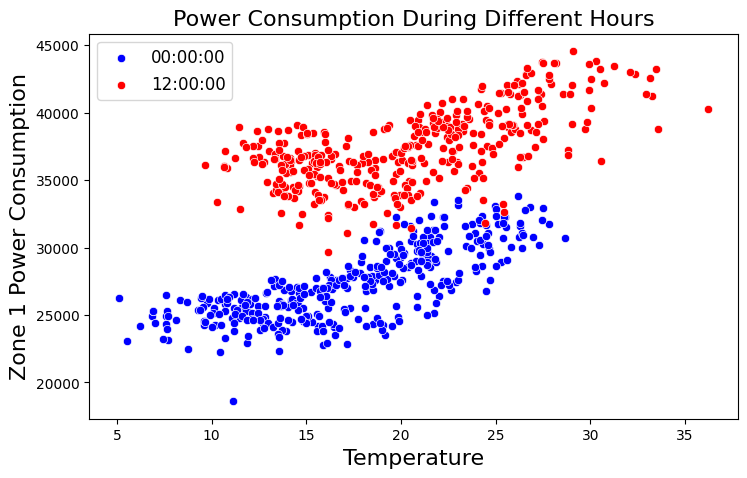

In [8]:
sns.pairplot(rawData, x_vars=['Temperature'], y_vars=['Zone 1 Power Consumption'], height=5, aspect=1.5)
plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.xlabel('Temperature', fontsize=16)
plt.show()

plt.figure(figsize=(8.37, 5))
sns.scatterplot(data=rawData_midnight, x='Temperature', y='Zone 1 Power Consumption', color='blue', label='00:00:00')
sns.scatterplot(data=rawData_noon, x='Temperature', y='Zone 1 Power Consumption', color='red', label='12:00:00')

plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.xlabel('Temperature', fontsize=16)
plt.title('Power Consumption During Different Hours', fontsize=16)
plt.legend(fontsize=12)
plt.show()

From this graph we can see the effect one would expect: that the summer period is where the temperatures would be hottest, sometimes reaching upwards of 35 to 40 degrees Celsius. This trend corresponds to what we see in the data, and what we were expecting. There tends to be more power usage during the summer months when it is hotter, likely due to the amount of climate control that is occuring.

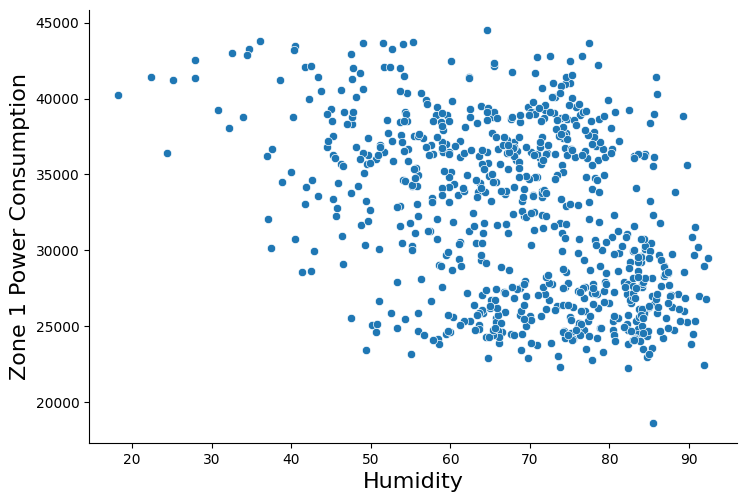

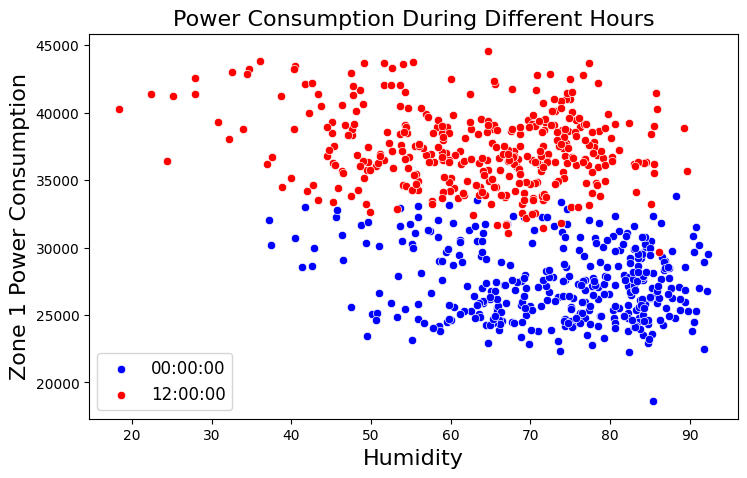

In [9]:
sns.pairplot(rawData, x_vars=['Humidity'], y_vars=['Zone 1 Power Consumption'], height=5, aspect=1.5)
plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.xlabel('Humidity', fontsize=16)
plt.show()

plt.figure(figsize=(8.37, 5))
sns.scatterplot(data=rawData_midnight, x='Humidity', y='Zone 1 Power Consumption', color='blue', label='00:00:00')
sns.scatterplot(data=rawData_noon, x='Humidity', y='Zone 1 Power Consumption', color='red', label='12:00:00')

plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.xlabel('Humidity', fontsize=16)
plt.title('Power Consumption During Different Hours', fontsize=16)
plt.legend(fontsize=12)
plt.show()

The mean humidity of this climate remained relatively similar for most of the year apart from a short time in the summer. Here we can see a steep drop in the mean humidity for approximately 10-20 days out of the year. There are more points in the early / late summer months that do have lower humidity; however they are more sparse among higher levels of humidity. This data appears like it could have some correlation to the power usage being at it's peak, but there does not appear to be anything to suggest that it contributes to the overall upward trend in the summer months.

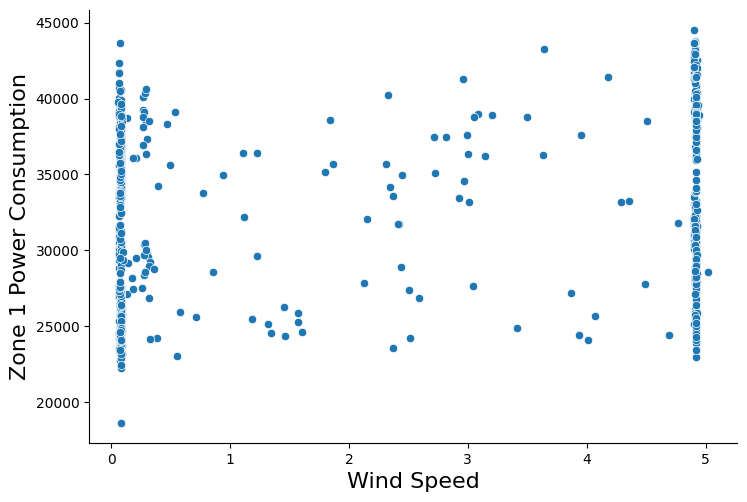

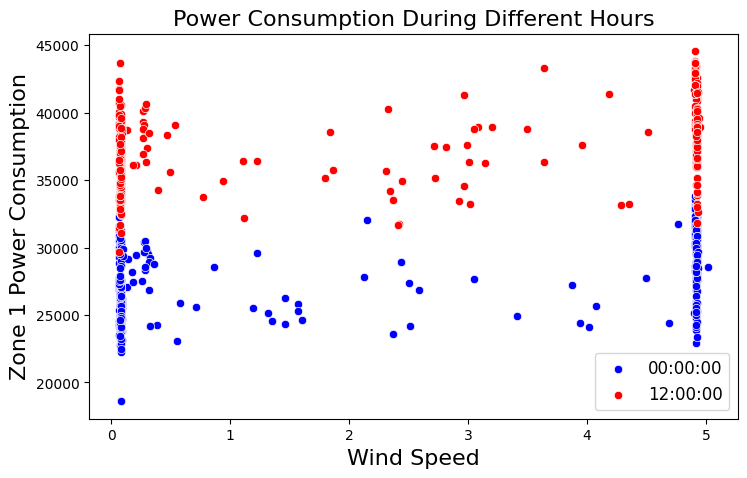

In [10]:
sns.pairplot(rawData, x_vars=['Wind Speed'], y_vars=['Zone 1 Power Consumption'], height=5, aspect=1.5)
plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.xlabel('Wind Speed', fontsize=16)
plt.show()

plt.figure(figsize=(8.37, 5))
sns.scatterplot(data=rawData_midnight, x='Wind Speed', y='Zone 1 Power Consumption', color='blue', label='00:00:00')
sns.scatterplot(data=rawData_noon, x='Wind Speed', y='Zone 1 Power Consumption', color='red', label='12:00:00')

plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.xlabel('Wind Speed', fontsize=16)
plt.title('Power Consumption During Different Hours', fontsize=16)
plt.legend(fontsize=12)
plt.show()

The wind speed over the year is a difficult piece of data to apply to any sort of trend. Since the data is meaned over every 12 hours then plotted day by day there are gusts that are likely causing some artifacts or changes in data, but there are some interesting things that can be taken from this graph. The most important of which being a tendency for the wind in the winter months to be much lower than that in the summer. Granted there are still *some* days that are about as windy as those found in the summer, given us a rather messy and polarizing data set that will most likely be confusing for the classical regression models that we are using.

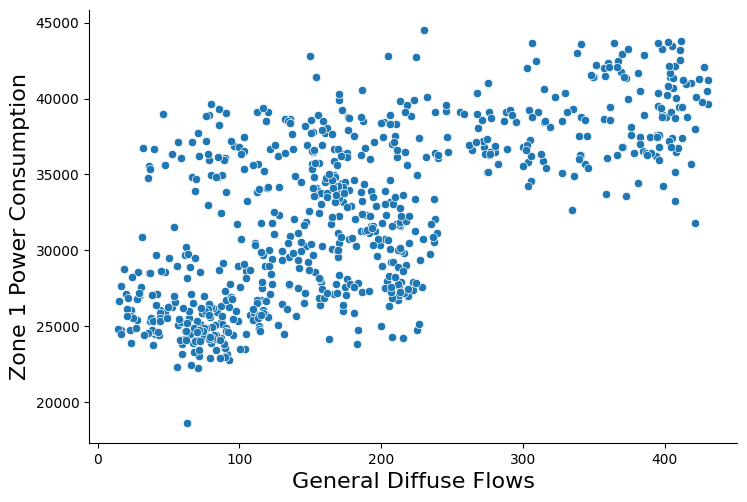

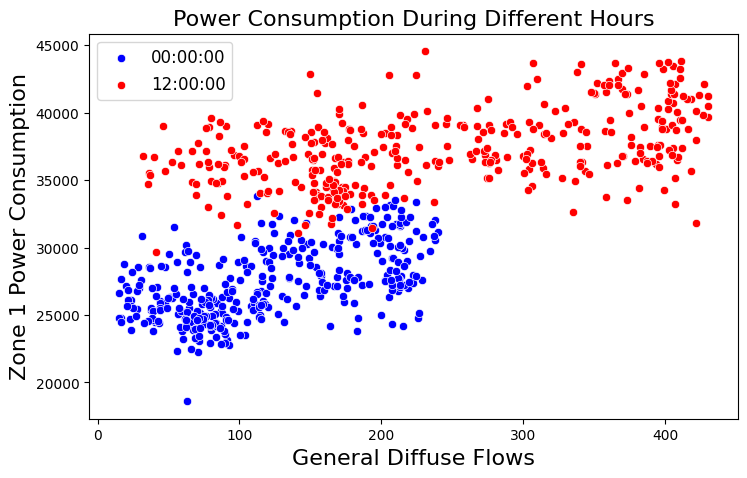

In [11]:
sns.pairplot(rawData, x_vars=['General Diffuse Flows'], y_vars=['Zone 1 Power Consumption'], height=5, aspect=1.5)
plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.xlabel('General Diffuse Flows', fontsize=16)
plt.show()

plt.figure(figsize=(8.37, 5))
sns.scatterplot(data=rawData_midnight, x='General Diffuse Flows', y='Zone 1 Power Consumption', color='blue', label='00:00:00')
sns.scatterplot(data=rawData_noon, x='General Diffuse Flows', y='Zone 1 Power Consumption', color='red', label='12:00:00')

plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.xlabel('General Diffuse Flows', fontsize=16)
plt.title('Power Consumption During Different Hours', fontsize=16)
plt.legend(fontsize=12)
plt.show()

The "general diffuse flows" or the Global diffuse flows have a much more clear trend, but surprisingly as with the power consumption there appears to be two congregations of data point density.

This again is most likely due to the 12 hour means that we have chosen. More analysis on the data will be required in order to understand if this data is implying that there is more rain during some hours of the day versus others.



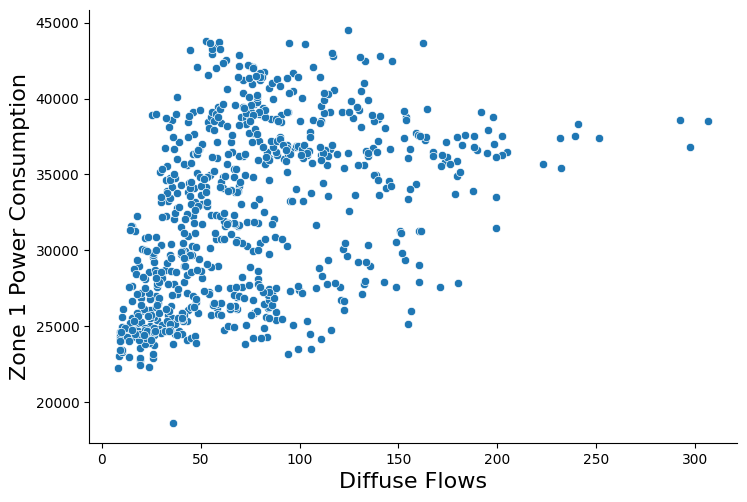

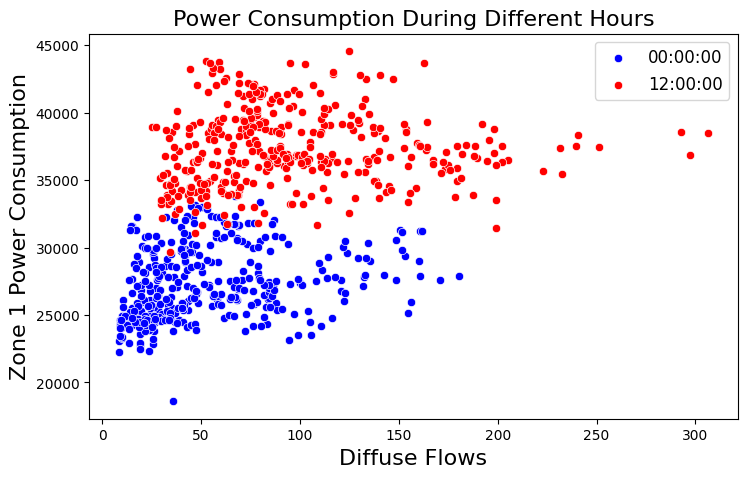

In [12]:
sns.pairplot(rawData, x_vars=['Diffuse Flows'], y_vars=['Zone 1 Power Consumption'], height=5, aspect=1.5)
plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.xlabel('Diffuse Flows', fontsize=16)
plt.show()

plt.figure(figsize=(8.37, 5))
sns.scatterplot(data=rawData_midnight, x='Diffuse Flows', y='Zone 1 Power Consumption', color='blue', label='00:00:00')
sns.scatterplot(data=rawData_noon, x='Diffuse Flows', y='Zone 1 Power Consumption', color='red', label='12:00:00')

plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.xlabel('Diffuse Flows', fontsize=16)
plt.title('Power Consumption During Different Hours', fontsize=16)
plt.legend(fontsize=12)
plt.show()

So we have some idea of what to expect for the variables that we will want to use for this machine learning model; however as humans we are terrible at determining numerical relations by eye. So instead we utilize more of the sklearn libraries to allow us to find the correlation between the accuracy of the model and the use of features in training the model.

Day: 0.570487
Temperature: 259.889097
Humidity: 22.358513
Wind Speed: 112.876139
General Diffuse Flows: 486.478977
Diffuse Flows: 127.076857
Day: 0.450392
Temperature: 0.000000
Humidity: 0.000003
Wind Speed: 0.000000
General Diffuse Flows: 0.000000
Diffuse Flows: 0.000000


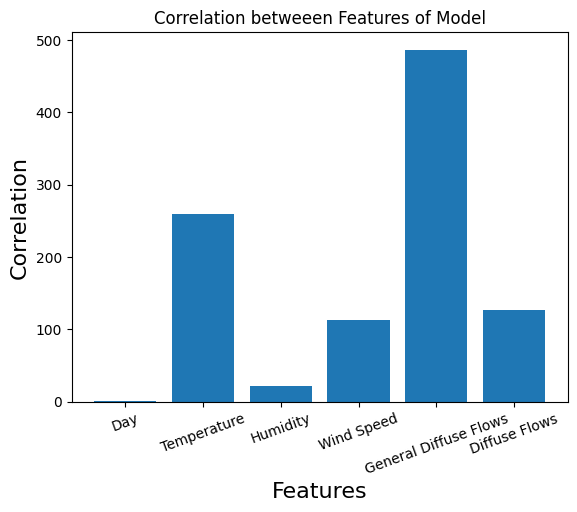

[Text(0.5, 0, 'Zone 1 Power Consumption'),
 Text(1.5, 0, 'Day'),
 Text(2.5, 0, 'Temperature'),
 Text(3.5, 0, 'Wind Speed'),
 Text(4.5, 0, 'Humidity'),
 Text(5.5, 0, 'General Diffuse Flows'),
 Text(6.5, 0, 'Diffuse Flows')]

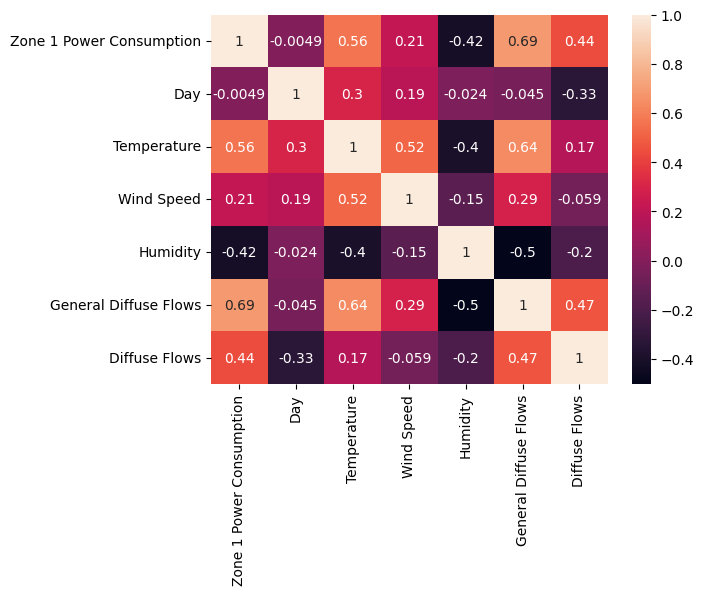

In [13]:
# Start with the
y = rawData[['Zone 1 Power Consumption']]
X = rawData[['Day', 'Temperature', 'Wind Speed', 'Humidity', 'General Diffuse Flows', 'Diffuse Flows']]
data = rawData[['Zone 1 Power Consumption', 'Day', 'Temperature', 'Wind Speed', 'Humidity', 'General Diffuse Flows', 'Diffuse Flows']]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75)

def select_features(X_train, y_train, X_test):
	# configure to select all features
	fs = SelectKBest(score_func=f_regression, k='all')
	# learn relationship from training data
	fs.fit(X_train, y_train.values.ravel()) # ravel is to change to a 1d numpy vector and not a data thing
  # transform data
	X_train_fs = fs.transform(X_train)
	X_test_fs = fs.transform(X_test)
	return X_train_fs, X_test_fs, fs

X_train_fs, X_test_fs, fs = select_features(X_train, y_train, X_test)
# Array for storing all of the features in the data
features=['Day', 'Temperature', 'Humidity', 'Wind Speed', 'General Diffuse Flows', 'Diffuse Flows']

for i in range(len(fs.scores_)):
 print('%s: %f' % (features[i], fs.scores_[i]))

for i in range(len(fs.scores_)):
 print('%s: %f' % (features[i], fs.pvalues_[i]))

# plot the scores
plt.bar([features for features in range(len(fs.scores_))], fs.scores_)
plt.xlabel('Features', fontsize=16)
plt.xticks(ticks=[0,1,2,3,4,5], labels=features, rotation = 20)

plt.ylabel('Correlation', fontsize=16)
plt.title('Correlation betweeen Features of Model')
plt.show()

plt.bar([features for features in range(len(fs.pvalues_))], fs.pvalues_)
plt.xlabel('Features', fontsize=16)
plt.xticks(ticks=[0,1,2,3,4,5], labels=features, rotation = 20)

# calculate the correlation matrix on the numeric columns
df = pd.DataFrame(data)
corr = df.corr()
# plot the heatmap
cm = sns.heatmap(corr, annot=True)
cm.set_yticklabels(cm.get_yticklabels(), rotation = 0, fontsize = 10)
cm.set_xticklabels(cm.get_xticklabels(), rotation = 90, fontsize = 10)


Here we can see the correlation between features. Perhaps interestingly (or at least interesting to me), the day of the year does not have any meaningful correlation to the data.

This makes sense on second thought, since the machine learning model does not know what a day is, let alone is able to understand the context of why it may be important.

The general diffuse flows are the most correlating model

The temperature of the system is the second most correlated feature, this makes sense as the power consumption plot compared to the temperature of the city can be visually inspected to have a strong correlation.

The humidity also does not appear to have any large contribution to the data, which makes sense given there was very little or no

# Models and Their Accuracy

It's clear based on the type of data set that we are working with that linear regression may not be the best model to predict features.

We can however expect that it will be more accurate than averaging the total dataset. How much will most likely depend on how well the features we choose correlate to the data.

Since we know the data we have is relevant to the day in the year, we still include this feature into our model so that we can make some sense of the plots. More analysis will be done in future to analyze the amount of power usage as a function of other select features, as these do correlate with the seasons all or some of the time.

In [14]:
# Get new data based on the recommendations of the correlation, leaving out Humidity and Days
y = rawData[['Zone 1 Power Consumption']]
X = rawData[['Day', 'Temperature', 'Wind Speed', 'General Diffuse Flows', 'Diffuse Flows']]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75)

mse_lin_avg = 0
r2_lin_avg = 0
for i in range(1000):
  lr = LinearRegression()
  lr.fit(X_train, y_train)
  y_pred = lr.predict(X_test)

  mse_lin_avg += np.sqrt(mean_squared_error(y_test, y_pred))
  r2_lin_avg += r2_score(y_test, y_pred)

mse_lin_avg = mse_lin_avg / 1000
r2_lin_avg = r2_lin_avg / 1000

print(f'\nMean Squared Error for Linear Approx: {mse_lin_avg}')
print(f'R-squared of Linear Approx: {r2_lin_avg}\n')


Mean Squared Error for Linear Approx: 4321.73859978736
R-squared of Linear Approx: 0.42989400729853056



Here we can see from the R-squared value is consistently somewhere between 50% to 60% on average better at predicting the future power usage than the total average of all data points.

We can also see that the mean squared error is approximately 4000 units of energy. This would imply that if we wanted to generate enough energy for the power grid, we would need to overestimate by at least that amount in order to ensure that the power grid would not try to use more power than what was being produced.

Max R-squared (Polynomial): 0.5528095760933307 Of Degree: 3

Mean Squared Error for Polynomial Approx: 4321.738599787353 



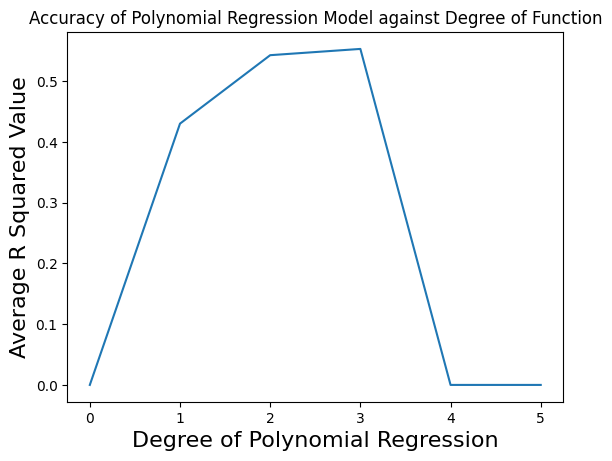

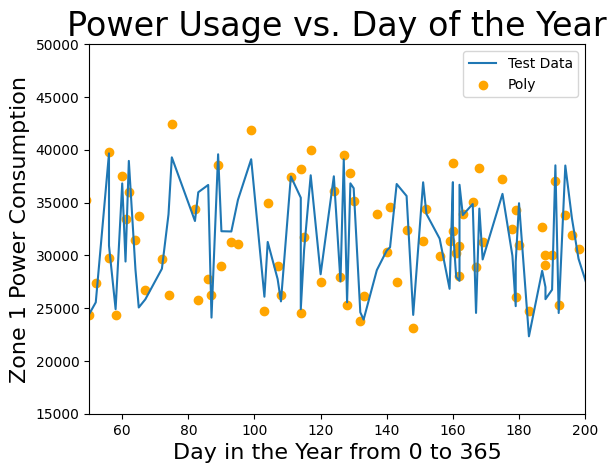

In [15]:
# Degree of the polynomial fit
degree = 0
# Maximum degree to iterate through
max_degree= 6
mse_poly_avg = [0 for element in range(max_degree)]
r2_poly_avg = [0 for element in range(max_degree)]

degrees = []

for j in range(max_degree):
  degrees.append(j)

# For polynomials of highest order 0 to max_degree
for degree in range(max_degree):
  # Average over many pipelines to get better statistics
  for i in range(100):
    # Make the pipeline for the polynomial regression model
    polyreg = make_pipeline(PolynomialFeatures(degree, include_bias=True), LinearRegression())

    polyreg.fit(X_train, y_train)

    y_pred_poly = polyreg.predict(X_test)

    mse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
    r2_poly = r2_score(y_test, y_pred_poly)

    mse_poly_avg[degree] += mse_lin_avg
    r2_poly_avg[degree] += r2_poly

  mse_poly_avg[degree] = mse_poly_avg[degree]/100
  r2_poly_avg[degree] = r2_poly_avg[degree]/100

  if(r2_poly_avg[degree] < 0):
      r2_poly_avg[degree] = 0


print(f'Max R-squared (Polynomial): {max(r2_poly_avg)} Of Degree: {r2_poly_avg.index(max(r2_poly_avg))}\n')
print(f'Mean Squared Error for Polynomial Approx: {mse_poly_avg[r2_poly_avg.index(max(r2_poly_avg))]} \n')

plt.plot(degrees, r2_poly_avg)
plt.ylabel('Average R Squared Value', fontsize=16)
plt.xlabel('Degree of Polynomial Regression', fontsize=16)
plt.title('Accuracy of Polynomial Regression Model against Degree of Function')
plt.show()

degree = r2_poly_avg.index(max(r2_poly_avg))
# Re-train model to get best fit
polyreg = make_pipeline(PolynomialFeatures(degree, include_bias=True), LinearRegression())

polyreg.fit(X_train, y_train)

y_pred_poly = polyreg.predict(X_test)

mse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

mse_poly_avg[degree] = 0
r2_poly_avg[degree] = 0

mse_poly_avg[degree] += mse_lin_avg
r2_poly_avg[degree] += r2_poly

mse_poly_avg[degree] = mse_poly_avg[degree]/100
r2_poly_avg[degree] = r2_poly_avg[degree]/100

plt.plot()

print('\n')

# Sort values so that they look prettier in plot
X_day_sort = X_test.sort_values(by='Day')

plt.plot(X_day_sort['Day'], y_test)
plt.scatter(X_day_sort['Day'], y_pred_poly, color='orange')

plt.xlabel('Day in the Year from 0 to 365', fontsize=16)
plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.axis([50, 200, 15000, 50000])
plt.legend(['Test Data', 'Poly'])
plt.title('Power Usage vs. Day of the Year', fontsize=24)
plt.show()

For the polynomial regression model, there appears to be a maximum accuracy rating of 70-80% with degree 3. This, as expected, is much better than the linear regression model. Increasing the degree of the model past 4 creates a large amount of overfitting to the training data causing a large drop in the accuracy of the model.

There is an interest in using other polynomial functions such as exponentials or sinusoidal functions given the nature of power fluctuations to repeatedly oscillate.

Max R-squared (DTR): 0.5311729308909957 Of Depth: 4

Mean Squared Error for DTR: 3919.1061939553315



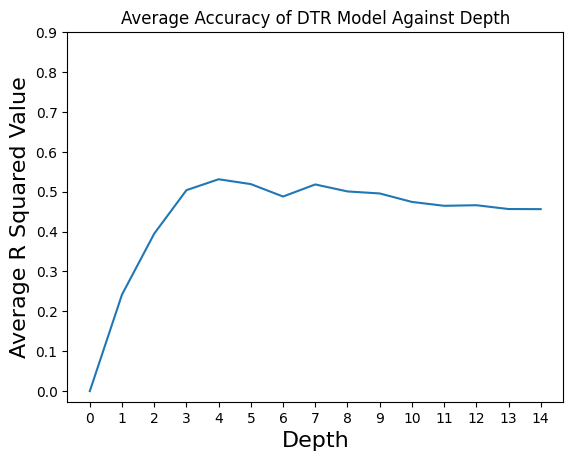

In [16]:
maxdepth=15
depths = [i for i in range(maxdepth)]
mse_dt_avg = [0 for element in range(maxdepth)]
r2_dt_avg = [0 for element in range(maxdepth)]

for depth in range(1, maxdepth):
  for i in range(100):
    dt_reg = DecisionTreeRegressor(max_depth=depth)  # Adjust max_depth
    dt_reg.fit(X_train, y_train)
    y_pred_dt = dt_reg.predict(X_test)

    mse_dt_avg[depth] += np.sqrt(mean_squared_error(y_test, y_pred_dt))
    r2_dt_avg[depth] += r2_score(y_test, y_pred_dt)

  mse_dt_avg[depth] = mse_dt_avg[depth] / 100
  r2_dt_avg[depth] = r2_dt_avg[depth] / 100


print(f'Max R-squared (DTR): {max(r2_dt_avg)} Of Depth: {r2_dt_avg.index(max(r2_dt_avg))}\n')
print(f'Mean Squared Error for DTR: {mse_dt_avg[r2_dt_avg.index(max(r2_dt_avg))]}\n')

plt.plot(depths, r2_dt_avg)
plt.xlabel('Depth', fontsize=16)
plt.ylabel('Average R Squared Value', fontsize=16)
plt.xticks(np.arange(0, maxdepth, step=1))
plt.yticks(np.arange(0, 1, step=0.1))
plt.title('Average Accuracy of DTR Model Against Depth')

depth = r2_dt_avg.index(max(r2_dt_avg))
# Re-train the model to the most accurate value
for i in range(100):
  dt_reg = DecisionTreeRegressor(max_depth = depth)  # Adjust max_depth
  dt_reg.fit(X_train, y_train)
  y_pred_dt = dt_reg.predict(X_test)

  mse_dt_avg[depth] = 0
  r2_dt_avg[depth] = 0

  mse_dt_avg[depth] += np.sqrt(mean_squared_error(y_test, y_pred_dt))
  r2_dt_avg[depth] += r2_score(y_test, y_pred_dt)

mse_dt_avg[depth] = mse_dt_avg[depth] / 100
r2_dt_avg[depth] = r2_dt_avg[depth] / 100


Decision tree regression (DTR) is a regression model that we have not seen before in our course.

DTR uses some complex mathmatics to split the data into many different pieces, using the information gain mathematics that we have previously learned in order to maximize the amount of information that is gained inside of each "piece" of the data. As these splits or sections of data are being created, the decision tree portion of the model is being developed alongside it. This decision tree looks for characteristics of the data in order to arrive at a prediction. A third dimension of the data is then used to predict the value of the target, this is the average of all values in each section of data that has been separated, and this will be the predictions for any new data points that fall into that section.

Intuitively this sounds like a good idea so long as the data we are using is highly correlated to the data. Since we are (for the moment) forced to use a feature that is neglibly correlated to the data, we expect that this will not provide a very large amount of accuracy.

Surprisingly, this model is found to be regularly almost as accurate as the polynomial regression method, also having about 60-70% accuracy when predicting the value of the power usage. This accuracy is achieved with the depth of the tree (or number of splits) to be around 7. We also find that the mean root squared error is smaller than the polynomial method used previously, so there could be a meaningful trade-off in terms of accuracy in order to save on the costs of over-generating power.

Max R-squared (RFR): 0.7462944207363119 Of Depth: 3

Mean Squared Error for RFR: 3640.7246092681794 



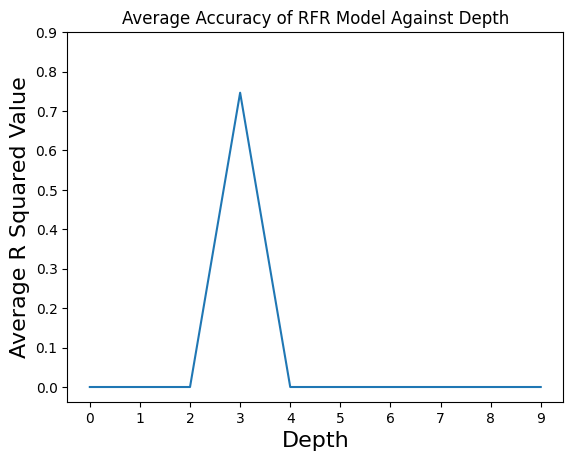

In [17]:
maxdepth=10
average_num = 10
depths = [i for i in range(maxdepth)]
mse_rf_avg = [0 for element in range(maxdepth)]
r2_rf_avg = [0 for element in range(maxdepth)]

for depth in range(1, maxdepth):
  for i in range(average_num):
    rf_reg = RandomForestRegressor(n_estimators=depth)  # Adjust max_depth
    rf_reg.fit(X_train, y_train.values.ravel())
    y_pred_rf = rf_reg.predict(X_test)

    mse_rf_avg[degree] += np.sqrt(mean_squared_error(y_test, y_pred_rf))
    r2_rf_avg[degree] += r2_score(y_test, y_pred_rf)

  r2_rf_avg[degree] = r2_rf_avg[degree] / average_num
  mse_rf_avg[degree] = mse_rf_avg[degree] / average_num

print(f'Max R-squared (RFR): {max(r2_rf_avg)} Of Depth: {r2_rf_avg.index(max(r2_rf_avg))}\n')
print(f'Mean Squared Error for RFR: {mse_rf_avg[r2_rf_avg.index(max(r2_rf_avg))]} \n')

plt.plot(depths, r2_rf_avg)
plt.xlabel('Depth', fontsize=16)
plt.ylabel('Average R Squared Value', fontsize=16)
plt.yticks(np.arange(0, 1, step=0.1))
plt.xticks(np.arange(0, maxdepth, step=1))
plt.title('Average Accuracy of RFR Model Against Depth')

# Retrain the model to the most accurate value
average_num = 25
for i in range(average_num):
    rf_reg = RandomForestRegressor(n_estimators=r2_rf_avg.index(max(r2_rf_avg)))  # Adjust max_depth
    rf_reg.fit(X_train, y_train.values.ravel())
    y_pred_rf = rf_reg.predict(X_test)

    mse_rf_avg[degree] += np.sqrt(mean_squared_error(y_test, y_pred_rf))
    r2_rf_avg[degree] += r2_score(y_test, y_pred_rf)

r2_rf_avg[degree] = r2_rf_avg[degree] / average_num
mse_rf_avg[degree] = mse_rf_avg[degree] / average_num

Since DTR worked very well, it stands to reason that creating more trees and abstracting the decision making process could prove to be very useful, as is the case here.

The random forrest regressor (RFR) is similar to the DTR method; however, it generates a series of trees parallel to each other, then makes a decision based on the average of all the predicitions. For this particular problem, the depth of the trees are only required to be about 3, which is a much simplier decision making process than the one that we used for the DTR.

As seen, this method is the most accurate between the four models that we have chosen. With an accuracy of about 80%, this could be an acceptable model to predict the use of electricity throughout the year. Due to this, we select this model as the one we will compare to the data we are trying to predict.

Not only is this model the most accurate, it also has the lowest mean root squared error out of all of the models that we have used. Further cementing the choice of model that we have made.

# Model Selection and Comparison to the Test Data

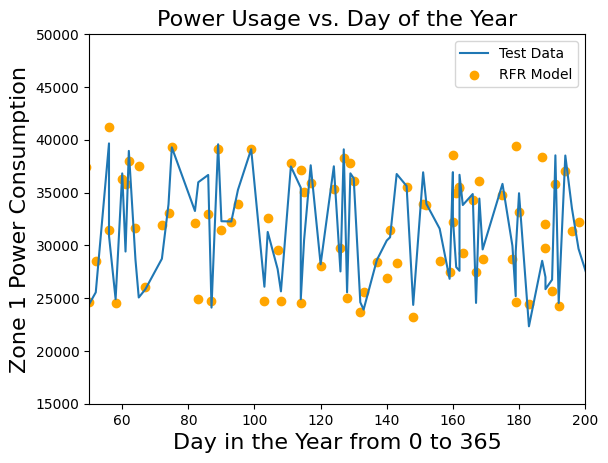

In [18]:
# Sort values so that they look prettier in plot
X_test = X_test.sort_values(by='Day')

plt.plot(X_test['Day'], y_test)
plt.scatter(X_test['Day'], y_pred_rf, color='orange')

plt.xlabel('Day in the Year from 0 to 365', fontsize=16)
plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.axis([50, 200, 15000, 50000])
plt.legend(['Test Data', 'RFR Model'])
plt.title('Power Usage vs. Day of the Year', fontsize=16)
plt.show()

Looking at this data we can see that this model tends to underestimate a little more than it tends to overestimate (at least for this portion of data). This gives the impression that displacing the power use by the mean root squared average (or perhaps two mean root squared averages for the purposes of redundancy) would be a worthwhile venture to decrease the chances of the power grid requesting more power than is available, and thus providing more efficiency to the amount of energy stored.

It is important to remember that the data that we are training off of is itself an average over every 12 hours in the day. So currently, this model cannot be used to determine the amount of energy to be generated minute by minute, but could provide good answers based on the predicted whether patterns of the day (which we know to at least be almost always accurate within 12 hours).

# Conclusion

Thus we have arrived at a model that we can use to within 80% accuracy predict the average amount of power that will be used in Tetuoan. This is a surprising result given that we did not account for overestimation to be an acceptable result when training these models, and opted for absolute accuracy as opposed to within an uncertainty value. These mathematical additions will have to be explored in more detail. Model improvements can also be made by decreasing the amount of time that we are averaging over to predict the power usage. This will allow predictions to be more accurate since the precursor data (weather) will be much easier to predict.

# Neural Network

Here we explore the use of neural networks for the use of predicting the use of power in an urban environment.

In [19]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from tensorflow.python.keras.layers import Dense
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline
from sklearn import preprocessing
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd

trueData = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CS 4120 Assignments/Tetuan City power consumption.csv", header=None, names=['DateTime',
                                                                                'Temperature',
                                                                                'Humidity',
                                                                                'Wind Speed',
                                                                                'General Diffuse Flows',
                                                                                'Diffuse Flows',
                                                                                'Zone 1 Power Consumption',
                                                                                'Zone 2 Power Consumption',
                                                                                'Zone 3 Power Consumption'], skiprows=1)

trueData['DateTime'] = pd.to_datetime(trueData['DateTime'], errors='coerce', format='%m/%d/%Y %H:%M')

#trueData.set_index('DateTime', inplace=True)

# Resample the data such that we are now measuring over every 12h in the year of the dataset
#rawData = trueData.resample('10min').mean()

#rawData['Day'] = (rawData.index - rawData.index.min()).days

y = trueData[['Zone 1 Power Consumption']]

X = trueData[['Temperature', 'Wind Speed', 'Humidity', 'General Diffuse Flows', 'Diffuse Flows']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the neural network model for regression
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='tanh', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='tanh'),
    tf.keras.layers.Dense(128, activation='tanh'),
    tf.keras.layers.Dense(128, activation='tanh'),
    tf.keras.layers.Dense(128, activation='tanh'),
    tf.keras.layers.Dense(128, activation='tanh'),
    tf.keras.layers.Dense(128, activation='tanh'),
    tf.keras.layers.Dense(1)  # Single output node for regression
])


model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

model.summary()

history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=0, batch_size=128)
y_pred_nn = model.predict(X_test)

r2 = r2_score(y_test, y_pred_nn)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)


print(f"Test accuracy: {r2}, MSE: {test_loss}")

predictions = model.predict(X_test)

# Sort values so that they look prettier in plot
X_test = X_test.sort_values(by='Temperature')

plt.plot(X_test['Temperature'], y_test)
plt.scatter(X_test['Temperature'], y_pred_nn, color='orange')

plt.xlabel('Temperature', fontsize=16)
plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.axis([18, 19, 13000, 55000])
plt.title('Power Usage vs. Temperature', fontsize=16)
plt.legend(['Test Data', 'NN'])
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/CS 4120 Assignments/Tetuan City power consumption.csv'

With and accuracy of about 30% for 100 epochs, this is a less than ideal attempt at trying to predict the power consumption for the city of Tetouan. Let us now move onto varying the model in an attempt to gain more accuracy.

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 8)                 48        
                                                                 
 dense_9 (Dense)             (None, 8)                 72        
                                                                 
 dense_10 (Dense)            (None, 8)                 72        
                                                                 
 dense_11 (Dense)            (None, 8)                 72        
                                                                 
 dense_12 (Dense)            (None, 8)                 72        
                                                                 
 dense_13 (Dense)            (None, 8)                 72        
                                                                 
 dense_14 (Dense)            (None, 8)                

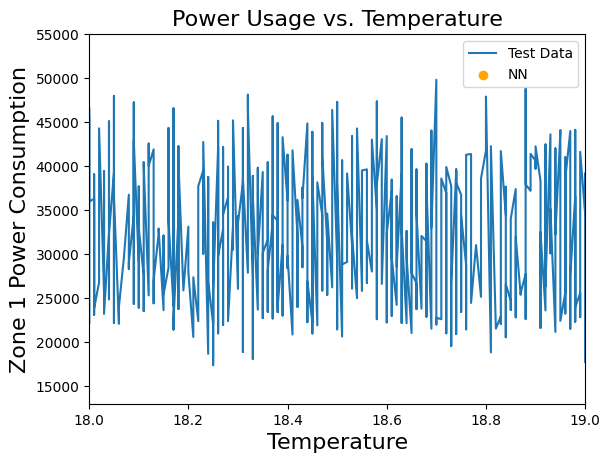

In [ ]:
# Define the neural network model for regression
model2 = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='tanh', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(8, activation='tanh'),
    tf.keras.layers.Dense(8, activation='tanh'),
    tf.keras.layers.Dense(8, activation='tanh'),
    tf.keras.layers.Dense(8, activation='tanh'),
    tf.keras.layers.Dense(8, activation='tanh'),
    tf.keras.layers.Dense(8, activation='tanh'),
    tf.keras.layers.Dense(1)  # Single output node for regression
])


model2.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

model2.summary()

history2 = model2.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=0, batch_size=100)
y_pred_nn = model2.predict(X_test)

r2 = r2_score(y_test, y_pred_nn)

test_loss, test_acc = model2.evaluate(X_test, y_test, verbose=0)


print(f"Test accuracy: {r2}, MSE: {test_acc}")

predictions = model2.predict(X_test)

# Sort values so that they look prettier in plot
X_test = X_test.sort_values(by='Temperature')

plt.plot(X_test['Temperature'], y_test)
plt.scatter(X_test['Temperature'], y_pred_nn, color='orange')

plt.xlabel('Temperature', fontsize=16)
plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.axis([18, 19, 13000, 55000])
plt.title('Power Usage vs. Temperature', fontsize=16)
plt.legend(['Test Data', 'NN'])
plt.show()


Here we have lowered the number of hidden nodes in the hope that the amount of variance decreases. This has in fact made the model less accurate that before, now being worse than the overall average of the values.

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 128)               768       
                                                                 
 dense_17 (Dense)            (None, 128)               16512     
                                                                 
 dense_18 (Dense)            (None, 64)                8256      
                                                                 
 dense_19 (Dense)            (None, 32)                2080      
                                                                 
 dense_20 (Dense)            (None, 16)                528       
                                                                 
 dense_21 (Dense)            (None, 8)                 136       
                                                                 
 dense_22 (Dense)            (None, 2)                

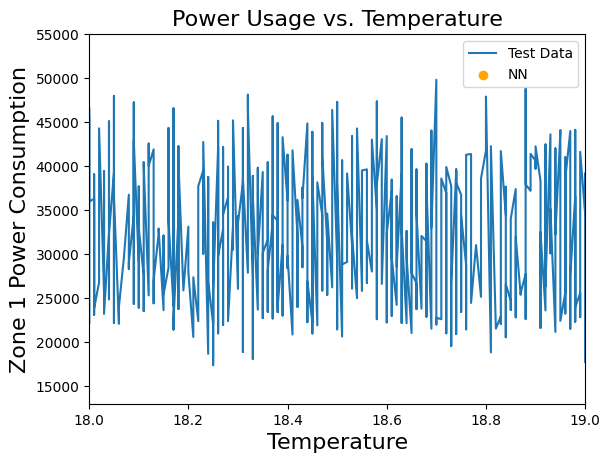

In [ ]:
# Define the neural network model for regression
model2 = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='tanh', input_shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(128, activation='tanh'),

    tf.keras.layers.Dense(64, activation='tanh'),

    tf.keras.layers.Dense(32, activation='tanh'),

    tf.keras.layers.Dense(16, activation='tanh'),

    tf.keras.layers.Dense(8, activation='tanh'),

    tf.keras.layers.Dense(2, activation='tanh'),

    tf.keras.layers.Dense(1)  # Single output node for regression
])


model2.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

model2.summary()

history2 = model2.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=0, batch_size=100)
y_pred_nn = model2.predict(X_test)

r2 = r2_score(y_test, y_pred_nn)

test_loss, test_acc = model2.evaluate(X_test, y_test, verbose=0)

print(f"Test accuracy: {r2}, MSE: {test_acc}")

predictions = model2.predict(X_test)

# Sort values so that they look prettier in plot
X_test = X_test.sort_values(by='Temperature')

plt.plot(X_test['Temperature'], y_test)
plt.scatter(X_test['Temperature'], y_pred_nn, color='orange')

plt.xlabel('Temperature', fontsize=16)
plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.axis([18, 19, 13000, 55000])
plt.title('Power Usage vs. Temperature', fontsize=16)
plt.legend(['Test Data', 'NN'])
plt.show()

"Funneling" the nodes does not appear to work either, causing even more variance and inaccuracies with the model. We move on to trying Convolutional Neural Networks in hopes that the increase in abstraction will allow for the network to use more complex calculations to predict the power consumption of the city.

328/328 [==============================] - 1s 2ms/step
Test accuracy: -15.595993339332466, MSE: 32293.619140625


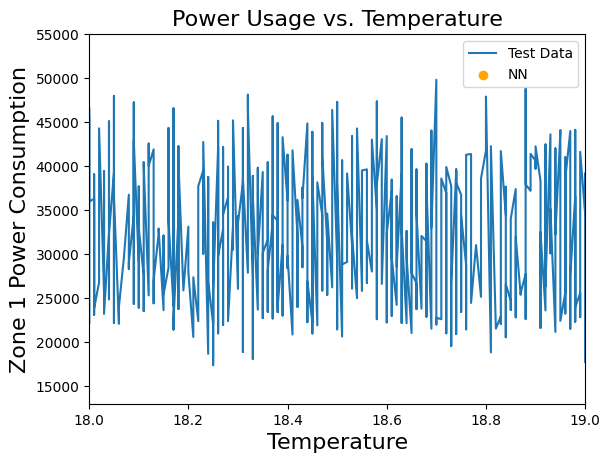

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

model = Sequential([
    # Convolutional layer: You can adjust the number of filters and kernel size based on your dataset
    Conv1D(32, kernel_size=5, activation='tanh', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=1),
    Conv1D(64, 5, activation='tanh', padding='same'),
    MaxPooling1D(pool_size=1),
    Flatten(),
    Dense(128, activation='tanh'),
    Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

history = model.fit(X_train, y_train, batch_size=100, epochs=100, validation_split=0.2, verbose=0)

test_loss, test_mae = model.evaluate(X_test, y_test)

y_pred_CNN = model.predict(X_test)

r2 = r2_score(y_test, y_pred_CNN)

# Sort values so that they look prettier in plot
X_test = X_test.sort_values(by='Temperature')

print(f"Test accuracy: {r2}, MSE: {test_acc}")

plt.plot(X_test['Temperature'], y_test)
plt.scatter(X_test['Temperature'], predictions, color='orange')

plt.xlabel('Temperature', fontsize=16)
plt.ylabel('Zone 1 Power Consumption', fontsize=16)
plt.axis([18, 19, 13000, 55000])
plt.title('Power Usage vs. Temperature', fontsize=16)
plt.legend(['Test Data', 'NN'])
plt.show()

This simple convolutional network was not very accurate either. So it seems to be the case that, at least for the models that we have tested for 100 epochs, that the neural network methods for the raw data we are trying to predict is not feasible.

Comparing to the previous accuracy obtained from even less accurate classical models, we can see that even the best neural network with an accuracy of 30% is half as accurate as even a mediocre classic model with an accuracy of 60%. The reason for this may be insufficient data for the neural network to properly train itself. If this is the case, it is likely that at least two years of data will be required in order to properly train the network. It may also be that the data is not properly formatted for the neural network to most accurate represent the data. In the paper that was published with this data, they formatted using multiple different algorithms before using machine learning techniques.

It is possible that there was simply not enough epochs used, or that the architecture of the neural networks was simply configured in such a manner that exacerbated the overfitting problem of the network.